# Important Libraries

In [58]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder , StandardScaler
import numpy as np
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix
from sklearn.tree import DecisionTreeClassifier

# Load Both Dataset 

Train dataset load

In [2]:
df_train =pd.read_csv("train.csv")

C:\Users\INTEL\AppData\Local\Temp\ipykernel_7472\1617190613.py:1: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train =pd.read_csv("train.csv")


Test dataset load

In [3]:
df_test = pd.read_csv("test.csv")

# Train Dataset

In [4]:
# see first 5 rows
df_train.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [5]:
# see the last 5 rows
df_train.tail()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
99995,0x25fe9,CUS_0x942c,April,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,_,502.38,34.663572,31 Years and 6 Months,No,35.104023,60.97133255718485,High_spent_Large_value_payments,479.866228,Poor
99996,0x25fea,CUS_0x942c,May,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,_,502.38,40.565631,31 Years and 7 Months,No,35.104023,54.18595028760385,High_spent_Medium_value_payments,496.65161,Poor
99997,0x25feb,CUS_0x942c,June,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,Good,502.38,41.255522,31 Years and 8 Months,No,35.104023,24.02847744864441,High_spent_Large_value_payments,516.809083,Poor
99998,0x25fec,CUS_0x942c,July,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,Good,502.38,33.638208,31 Years and 9 Months,No,35.104023,251.67258219721603,Low_spent_Large_value_payments,319.164979,Standard
99999,0x25fed,CUS_0x942c,August,Nicks,25,078-73-5990,Mechanic,39628.99_,3359.415833,4,...,Good,502.38,34.192463,31 Years and 10 Months,No,35.104023,167.1638651610451,!@9#%8,393.673696,Poor


In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

 In the train dataset , there are almost 28 columns where 4 float , 4 int and rest of them are object 

In [7]:
df_train.describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,84998.000000,100000.000000,100000.00000,100000.000000,100000.000000,98035.000000,100000.000000,100000.000000
mean,4194.170850,17.091280,22.47443,72.466040,21.068780,27.754251,32.285173,1403.118217
std,3183.686167,117.404834,129.05741,466.422621,14.860104,193.177339,5.116875,8306.041270
min,303.645417,-1.000000,0.00000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1625.568229,3.000000,4.00000,8.000000,10.000000,3.000000,28.052567,30.306660
50%,3093.745000,6.000000,5.00000,13.000000,18.000000,6.000000,32.305784,69.249473
75%,5957.448333,7.000000,7.00000,20.000000,28.000000,9.000000,36.496663,161.224249
max,15204.633333,1798.000000,1499.00000,5797.000000,67.000000,2597.000000,50.000000,82331.000000


In [8]:
df_train.shape

(100000, 28)

In [9]:
df_train.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

#  Exploratory Data Analysis for Train dataset

In [10]:
# drop unnecessary columns
df_train = df_train.drop(['ID','Customer_ID','Month','SSN','Name'], axis=1)

In [11]:
df_train.isnull().sum()

Age                             0
Occupation                      0
Annual_Income                   0
Monthly_Inhand_Salary       15002
Num_Bank_Accounts               0
Num_Credit_Card                 0
Interest_Rate                   0
Num_of_Loan                     0
Type_of_Loan                11408
Delay_from_due_date             0
Num_of_Delayed_Payment       7002
Changed_Credit_Limit            0
Num_Credit_Inquiries         1965
Credit_Mix                      0
Outstanding_Debt                0
Credit_Utilization_Ratio        0
Credit_History_Age           9030
Payment_of_Min_Amount           0
Total_EMI_per_month             0
Amount_invested_monthly      4479
Payment_Behaviour               0
Monthly_Balance              1200
Credit_Score                    0
dtype: int64

# Handling missing values

In [12]:
df_train["Age"] = df_train["Age"].astype(str).str.replace("_", "", regex=False)

In [13]:
df_train["Age"] = pd.to_numeric(df_train["Age"], errors="coerce")

In [14]:
df_train["Age"] = pd.to_numeric(df_train["Age"], errors="coerce")

In [15]:
df_train["Age"] = df_train["Age"].fillna(df_train["Age"].median())

In [16]:
df_train['Monthly_Inhand_Salary'] = df_train['Monthly_Inhand_Salary'].fillna(df_train['Monthly_Inhand_Salary'].mean())

In [17]:
df_train['Type_of_Loan'] = df_train['Type_of_Loan'].fillna(df_train['Type_of_Loan'].mode()[0])

In [18]:
df_train['Num_of_Delayed_Payment'] = df_train['Num_of_Delayed_Payment'].fillna(df_train['Num_of_Delayed_Payment'].mode()[0])

In [19]:
df_train['Num_Credit_Inquiries']= df_train['Num_Credit_Inquiries'].fillna(df_train['Num_Credit_Inquiries'].std())

In [20]:
import re
import numpy as np

def convert_to_months(x):
    if pd.isna(x):
        return np.nan

    match = re.search(r'(\d+)\s+Years?\s+and\s+(\d+)\s+Months?', str(x))
    if match:
        years = int(match.group(1))
        months = int(match.group(2))
        return years * 12 + months

    return np.nan

df_train["Credit_History_Age"] = df_train["Credit_History_Age"].apply(convert_to_months)

In [21]:
df_train["Credit_History_Age"] = df_train["Credit_History_Age"].fillna(df_train["Credit_History_Age"].median())

In [22]:
df_train["Amount_invested_monthly"] = df_train["Amount_invested_monthly"].replace("--100--", 100)

In [23]:
df_train['Amount_invested_monthly']= df_train['Amount_invested_monthly'].fillna(df_train['Amount_invested_monthly'].mode()[0])

In [24]:
df_train["Monthly_Balance"] = pd.to_numeric(df_train["Monthly_Balance"],errors="coerce")
df_train['Monthly_Balance'] = df_train['Monthly_Balance'].fillna(df_train['Monthly_Balance'].median())

In [25]:
df_train['Credit_History_Age'] = df_train['Credit_History_Age'].fillna(df_train['Credit_History_Age'].mean())

In [26]:
df_train.isnull().sum()

Age                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Type_of_Loan                0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
Credit_Score                0
dtype: int64

Finally handling the nan values on the train dataset

In [27]:
df_train.duplicated().sum()

np.int64(0)

# Test Dataset

In [28]:
df_test.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,0x160a,CUS_0xd40,September,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,2022.0,Good,809.98,35.030402,22 Years and 9 Months,No,49.574949,236.64268203272135,Low_spent_Small_value_payments,186.26670208571772
1,0x160b,CUS_0xd40,October,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,...,4.0,Good,809.98,33.053114,22 Years and 10 Months,No,49.574949,21.465380264657146,High_spent_Medium_value_payments,361.44400385378196
2,0x160c,CUS_0xd40,November,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,...,4.0,Good,809.98,33.811894,NaN,No,49.574949,148.23393788500925,Low_spent_Medium_value_payments,264.67544623342997
3,0x160d,CUS_0xd40,December,Aaron Maashoh,24_,821-00-0265,Scientist,19114.12,NaN,3,...,4.0,Good,809.98,32.430559,23 Years and 0 Months,No,49.574949,39.08251089460281,High_spent_Medium_value_payments,343.82687322383634
4,0x1616,CUS_0x21b1,September,Rick Rothackerj,28,004-07-5839,_______,34847.84,3037.986667,2,...,5.0,Good,605.03,25.926822,27 Years and 3 Months,No,18.816215,39.684018417945296,High_spent_Large_value_payments,485.2984336755923


In [29]:
df_test.tail()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
49995,0x25fe5,CUS_0x8600,December,Sarah McBridec,4975,031-35-0942,Architect,20002.88,1929.906667,10,...,12.0,_,3571.7,34.780553,NaN,Yes,60.964772,146.48632477751087,Low_spent_Small_value_payments,275.53956951573343
49996,0x25fee,CUS_0x942c,September,Nicks,25,078-73-5990,Mechanic,39628.99,NaN,4,...,7.0,Good,502.38,27.758522,31 Years and 11 Months,NM,35.104023,181.44299902757518,Low_spent_Small_value_payments,409.39456169535066
49997,0x25fef,CUS_0x942c,October,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,7.0,Good,502.38,36.858542,32 Years and 0 Months,No,35.104023,__10000__,Low_spent_Large_value_payments,349.7263321025098
49998,0x25ff0,CUS_0x942c,November,Nicks,25,078-73-5990,Mechanic,39628.99,NaN,4,...,7.0,Good,502.38,39.139840,32 Years and 1 Months,No,35.104023,97.59857973344877,High_spent_Small_value_payments,463.23898098947717
49999,0x25ff1,CUS_0x942c,December,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,7.0,_,502.38,34.108530,32 Years and 2 Months,No,35.104023,220.45787812168732,Low_spent_Medium_value_payments,360.37968260123847


In [30]:
df_test.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance'],
      dtype='object')

In [31]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        50000 non-null  object 
 1   Customer_ID               50000 non-null  object 
 2   Month                     50000 non-null  object 
 3   Name                      44985 non-null  object 
 4   Age                       50000 non-null  object 
 5   SSN                       50000 non-null  object 
 6   Occupation                50000 non-null  object 
 7   Annual_Income             50000 non-null  object 
 8   Monthly_Inhand_Salary     42502 non-null  float64
 9   Num_Bank_Accounts         50000 non-null  int64  
 10  Num_Credit_Card           50000 non-null  int64  
 11  Interest_Rate             50000 non-null  int64  
 12  Num_of_Loan               50000 non-null  object 
 13  Type_of_Loan              44296 non-null  object 
 14  Delay_

There are almost 27 columns where float are 4 and int are 4 and rest of them are object type data type

In [32]:
df_test.describe().T

,count,mean,std,min,25%,50%,75%,max
Monthly_Inhand_Salary,42502.0,4182.004291,3174.109304,303.645417,1625.188333,3086.305000,5934.189094,15204.633333
Num_Bank_Accounts,50000.0,16.838260,116.396848,-1.000000,3.000000,6.000000,7.000000,1798.000000
Num_Credit_Card,50000.0,22.921480,129.314804,0.000000,4.000000,5.000000,7.000000,1499.000000
Interest_Rate,50000.0,68.772640,451.602363,1.000000,8.000000,13.000000,20.000000,5799.000000
Delay_from_due_date,50000.0,21.052640,14.860397,-5.000000,10.000000,18.000000,28.000000,67.000000
Num_Credit_Inquiries,48965.0,30.080200,196.984121,0.000000,4.000000,7.000000,10.000000,2593.000000
Credit_Utilization_Ratio,50000.0,32.279581,5.106238,20.509652,28.061040,32.280390,36.468591,48.540663
Total_EMI_per_month,50000.0,1491.304305,8595.647887,0.000000,32.222388,74.733349,176.157491,82398.000000


In [33]:
df_test.shape

(50000, 27)

In [34]:
df_test.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance'],
      dtype='object')

#  Exploratory Data Analysis for Test dataset

In [35]:
# drop unnecessary columns
df_test = df_test.drop(['ID','Customer_ID','Month','SSN','Name'], axis=1)

In [36]:
df_test.isnull().sum()

Age                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary       7498
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Type_of_Loan                5704
Delay_from_due_date            0
Num_of_Delayed_Payment      3498
Changed_Credit_Limit           0
Num_Credit_Inquiries        1035
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age          4470
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly     2271
Payment_Behaviour              0
Monthly_Balance              562
dtype: int64

# Handling missing values

In [37]:
df_test['Age'].unique()[:60]

array(['23', '24', '24_', '28', '35', '55', '22', '31', '32', '1694',
       '34', '30', '914', '45', '41_', '41', '33', '36', '39', '40',
       '40_', '37', '21', '46', '26', '27', '32_', '42', '42_', '20',
       '48', '49', '33_', '38', '38_', '44', '-500', '16', '17', '37_',
       '19_', '19', '3193', '43', '339', '14', '15', '25', '21_', '1203',
       '46_', '2823', '22_', '18', '47', '1643', '20_', '35_', '8327_',
       '29'], dtype=object)

In [38]:
df_test["Age"] = df_test["Age"].astype(str).str.replace("_", "", regex=False)

In [39]:
df_test["Age"] = pd.to_numeric(df_test["Age"], errors="coerce")

In [40]:
df_test["Age"] = df_test["Age"].fillna(df_test["Age"].median())

In [41]:
df_test['Monthly_Inhand_Salary'] = df_test['Monthly_Inhand_Salary'].fillna(df_test['Monthly_Inhand_Salary'].mean())

In [42]:
df_test['Type_of_Loan'] = df_test['Type_of_Loan'].fillna(df_test['Type_of_Loan'].mode()[0])

In [43]:
import re
import numpy as np

def convert_to_months(x):
    if pd.isna(x):
        return np.nan

    match = re.search(r'(\d+)\s+Years?\s+and\s+(\d+)\s+Months?', str(x))
    if match:
        years = int(match.group(1))
        months = int(match.group(2))
        return years * 12 + months

    return np.nan

df_test["Credit_History_Age"] = df_test["Credit_History_Age"].apply(convert_to_months)

In [44]:
df_test["Credit_History_Age"] = df_test["Credit_History_Age"].fillna(df_test["Credit_History_Age"].median())

In [45]:
df_test['Num_of_Delayed_Payment'] = df_test['Num_of_Delayed_Payment'].fillna(df_test['Num_of_Delayed_Payment'].mode()[0])

In [46]:
df_test['Num_Credit_Inquiries'] =df_test['Num_Credit_Inquiries'].fillna(df_test['Num_Credit_Inquiries'].mean())

In [47]:
df_test["Amount_invested_monthly"] = df_test["Amount_invested_monthly"].replace("--100--", 100)

In [48]:
df_test['Amount_invested_monthly']= df_test['Amount_invested_monthly'].fillna(df_test['Amount_invested_monthly'].mode()[0])

In [49]:
df_test["Monthly_Balance"] = pd.to_numeric(df_test["Monthly_Balance"],errors="coerce")
df_test['Monthly_Balance'] = df_test['Monthly_Balance'].fillna(df_test['Monthly_Balance'].median())

In [50]:
df_test.isna().sum()

Age                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Type_of_Loan                0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
dtype: int64

Handling All missing values 

In [51]:
# Check Duplicate values for test values
df_test.duplicated().sum()

np.int64(0)

# **Dataset spliting and Performing Encoding and Scalling for Train dataset**

In [52]:
x =df_train.drop(['Credit_Score'],axis=1)
y = df_train['Credit_Score']

In [64]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df_train.select_dtypes(include='object').columns:
    df_train[col] = le.fit_transform(df_train[col].astype(str))

for col in df_test.select_dtypes(include='object').columns:
    df_test[col] = le.fit_transform(df_test[col].astype(str))

# Performing Train Test Split

In [54]:
xtrain , xtest , ytrain , ytest = train_test_split(x,y, test_size=.25, random_state=42)

In [55]:
print(le.classes_)

['Good' 'Poor' 'Standard']


Here 
0 -> Good
1 -> Poor
2 -> Standard

# Model Evalution

Catboost

In [56]:

cat_features = [col for col in xtrain.columns if xtrain[col].dtype == 'object']
print("Cat features:", cat_features)

cat = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6, random_state=42, verbose=100)

model_cat = cat.fit(xtrain, ytrain, eval_set=(xtest, ytest),cat_features=cat_features)  
print('Training Model Score:', model_cat.score(xtrain, ytrain))

Cat features: ['Occupation', 'Annual_Income', 'Num_of_Loan', 'Type_of_Loan', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Credit_Mix', 'Outstanding_Debt', 'Payment_of_Min_Amount', 'Amount_invested_monthly', 'Payment_Behaviour']
0:	learn: 1.0526998	test: 1.0463813	best: 1.0463813 (0)	total: 339ms	remaining: 2m 48s


KeyboardInterrupt: 

In [ ]:
# Training Accuracy
train_pred = cat.predict(xtrain)
print('Training Accuracy:', accuracy_score(ytrain, train_pred))

# Validation/Test Accuracy
test_pred = cat.predict(xtest)
print('Testing  Accuracy:', accuracy_score(ytest, test_pred))

Training Accuracy: 0.8543733333333333
Testing  Accuracy: 0.82148


In [ ]:
train_acc = accuracy_score(ytrain, train_pred)
test_acc  = accuracy_score(ytest, test_pred)

print(f'  Training Accuracy  : {train_acc*100:.2f}%')
print(f'  Validation Accuracy: {test_acc*100:.2f}%')

  Training Accuracy  : 85.44%
  Validation Accuracy: 82.15%


In [ ]:
print(classification_report(ytest, test_pred, target_names=le.classes_))

              precision    recall  f1-score   support

        Good       0.77      0.83      0.80      4422
        Poor       0.78      0.89      0.83      7313
    Standard       0.87      0.78      0.82     13265

    accuracy                           0.82     25000
   macro avg       0.81      0.83      0.82     25000
weighted avg       0.83      0.82      0.82     25000



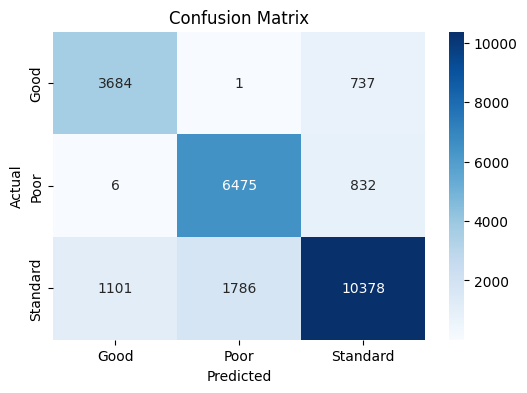

In [ ]:
cm = confusion_matrix(ytest, test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# **Apply Decision tree classifire**

In [62]:
dt = DecisionTreeClassifier(random_state=42,max_depth=10)

model_dt = dt.fit(x,y)
print("Training Score", model_dt.score(x,y))

ValueError: could not convert string to float: 'Scientist'

In [63]:
print(df_train.select_dtypes(include="object").columns)

Index(['Occupation', 'Annual_Income', 'Num_of_Loan', 'Type_of_Loan',
       'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Credit_Mix',
       'Outstanding_Debt', 'Payment_of_Min_Amount', 'Amount_invested_monthly',
       'Payment_Behaviour', 'Credit_Score'],
      dtype='object')
